In [1]:
#  1. Import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from keras.models import Sequential
from keras.layers import GRU, Dense
from datetime import timedelta
from google.colab import drive


In [2]:
# 2. Đọc dữ liệu
drive.mount('/content/drive')
train_path= "/content/drive/MyDrive/PTDLKD/Processed/6_2_2/btc_train.csv"
val_path= "/content/drive/MyDrive/PTDLKD/Processed/6_2_2/btc_val.csv"
test_path= "/content/drive/MyDrive/PTDLKD/Processed/6_2_2/btc_test.csv"
features = ['Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

for df in [train_df, val_df, test_df]:
    df['Date'] = pd.to_datetime(df['Date'])
train_df.head()

Mounted at /content/drive


,Date,Price,Open,High,Low,Vol.,Change %
0,2020-01-01,7199.8,7196.4,7259.4,7180.0,420280.0,0.05
1,2020-01-02,6967.0,7199.7,7209.6,6901.4,632780.0,-3.23
2,2020-01-03,7343.1,6967.1,7402.9,6884.1,936290.0,5.40
3,2020-01-04,7376.8,7345.1,7433.1,7291.4,523910.0,0.46
4,2020-01-05,7372.5,7376.8,7501.0,7345.6,628140.0,-0.06


In [3]:
# 3. Chuẩn hóa dữ liệu
scaler = MinMaxScaler()
# Tạo một đối tượng scaler từ lớp MinMaxScaler của thư viện sklearn.preprocessing
train_scaled = scaler.fit_transform(train_df[features])
# Cái đầu dùng fit_transform nhưng cái sau dùng transform bởi vì dùng fit_transform là đã học tham số từ dữ liệu
val_scaled = scaler.transform(val_df[features])
test_scaled = scaler.transform(test_df[features])
print(train_scaled[:5])

[[3.78585019e-02 3.79694962e-02 2.97086039e-02 5.29973393e-02
  9.39642113e-05 6.69568186e-01]
 [3.41456957e-02 3.80221165e-02 2.89258472e-02 4.85372702e-02
  1.41503364e-04 6.13585936e-01]
 [4.01439191e-02 3.43131862e-02 3.19641378e-02 4.82603169e-02
  2.09402697e-04 7.60880696e-01]
 [4.06813829e-02 4.03405965e-02 3.24388216e-02 5.47807266e-02
  1.17147658e-04 6.76565967e-01]
 [4.06128044e-02 4.08460698e-02 3.35060742e-02 5.56484070e-02
  1.40465333e-04 6.67690732e-01]]


In [4]:
# 4. Tạo chuỗi thời gian
TIME_STEP = 100
target_index = features.index('Price')

def create_sequences(data):
    X, y = [], []
    for i in range(len(data) - TIME_STEP):
        X.append(data[i:i+TIME_STEP])
        y.append(data[i+TIME_STEP, target_index])
    return np.array(X), np.array(y)
# Mục tiêu của create_sequences là biến đổi dữ liệu đầu vào thành các chuỗi (sequence) đầu vào và nhãn đầu ra,
X_train, y_train = create_sequences(train_scaled)
X_val, y_val = create_sequences(val_scaled)
X_test, y_test = create_sequences(test_scaled)

In [5]:
# 5. Xây dựng mô hình GRU
model = Sequential([
    GRU(64, return_sequences=True, input_shape=(TIME_STEP, len(features))),
    GRU(32),
    Dense(1)
])
# sequential là một class trong thư viện Keras, được dùng để xây dựng mô hình mạng thần kinh một cách tuần tự

model.compile(optimizer='adam', loss='mean_squared_error')
history = model.fit(X_train, y_train, epochs=10, batch_size=16, validation_data=(X_val, y_val), verbose=1)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 15s 153ms/step - loss: 0.0581 - val_loss: 6.4359e-04
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 8s 124ms/step - loss: 0.0012 - val_loss: 5.3310e-04
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 12s 147ms/step - loss: 0.0011 - val_loss: 4.6895e-04
Epoch 4/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 10s 144ms/step - loss: 8.6706e-04 - val_loss: 4.3240e-04
Epoch 5/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - loss: 7.8075e-04 - val_loss: 6.3075e-04
Epoch 6/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 12s 144ms/step - loss: 7.3952e-04 - val_loss: 2.9565e-04
Epoch 7/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 10s 151ms/step - loss: 6.1882e-04 - val_loss: 2.6931e-04
Epoch 8/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - loss: 4.9535e-04 - val_loss: 2.7317e-04
Epoch 9/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 10s 149ms/step - loss: 5.4056e-04 - val_loss: 3.2527e-04
Epoch 10/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 9s 125ms/step - loss: 4.6290e-04 - val_loss: 3.4412e-04


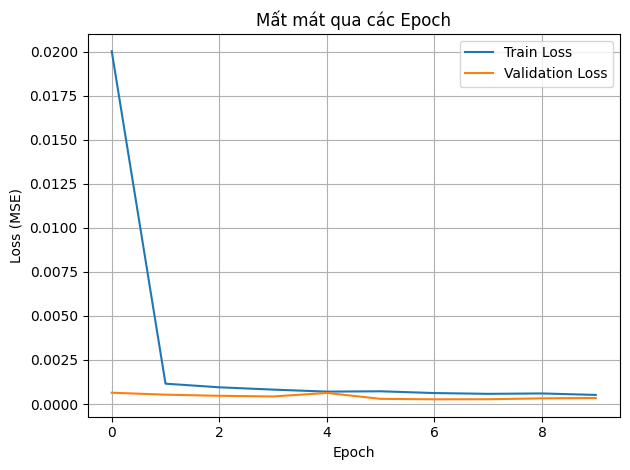

In [6]:
# 7. Biểu đồ loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Mất mát qua các Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [7]:
# Đánh giá mô hình sau khi train xong
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
import numpy as np

# Dự đoán trên tập test (chuẩn hoá)
pred_test_scaled = model.predict(X_test)

# Hàm giải chuẩn hoá để lấy lại giá gốc
def inverse_price(pred):
    dummy = np.zeros((len(pred), len(features)))
    dummy[:, target_index] = pred[:, 0] if pred.ndim > 1 else pred
    return scaler.inverse_transform(dummy)[:, target_index]

# 🔁 Giải chuẩn hoá trước khi đánh giá
y_test_rescaled = inverse_price(y_test)
y_pred_test_rescaled = inverse_price(pred_test_scaled)

# ✅ Tính các chỉ số đánh giá
mape = mean_absolute_percentage_error(y_test_rescaled, y_pred_test_rescaled) * 100
rmse = np.sqrt(mean_squared_error(y_test_rescaled, y_pred_test_rescaled))
mse = mean_squared_error(y_test_rescaled, y_pred_test_rescaled)
mae = mean_absolute_error(y_test_rescaled, y_pred_test_rescaled)
r2 = r2_score(y_test_rescaled, y_pred_test_rescaled)
# ✅ In kết quả
print(f"MAPE (test): {mape:.2f}%")
print(f"RMSE (test): {rmse:.4f}")
print(f"MSE  (test): {mse:.4f}")
print(f"MAE  (test): {mae:.4f}")
print(f"R^2  (test): {r2:.4f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 132ms/step
MAPE (test): 5.01%
RMSE (test): 5133.4912
MSE  (test): 26352731.6725
MAE  (test): 4202.0748
R^2  (test): 0.9079


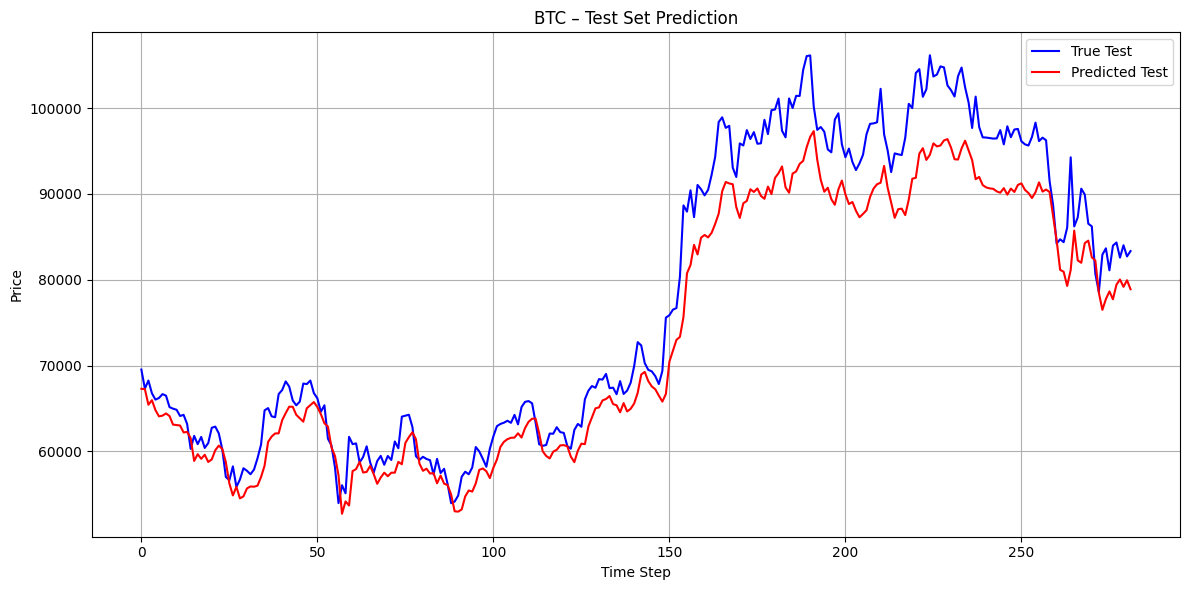

In [8]:
# 9. Biểu đồ giá thật vs dự đoán
coin= 'btc'
plt.figure(figsize=(12, 6))
plt.plot(y_test_rescaled, label="True Test", color='blue')
plt.plot(y_pred_test_rescaled, label="Predicted Test", color='red')
plt.title(f"{coin.upper()} – Test Set Prediction")
plt.xlabel("Time Step")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [9]:
# Dự báo rolling 90 ngày từ chuỗi cuối cùng của test_scaled
last_seq = test_scaled[-TIME_STEP:]  # test_scaled: chuẩn hóa test với đầy đủ n_features

def predict_future_multivariate(model, last_seq, n_days, scaler, target_index):
    preds = []
    seq = last_seq.copy()
    for _ in range(n_days):
        x_input = seq.reshape(1, *seq.shape)
        yhat = model.predict(x_input, verbose=0)[0, 0]
        new_step = seq[-1].copy()
        new_step[target_index] = yhat
        seq = np.vstack([seq[1:], [new_step]])
        preds.append(yhat)
    dummy = np.zeros((len(preds), seq.shape[1]))
    dummy[:, target_index] = preds
    return scaler.inverse_transform(dummy)[:, target_index]

# 🔁 Tạo future_90_rescaled đúng
future_90_rescaled = predict_future_multivariate(model, last_seq, 90, scaler, target_index)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


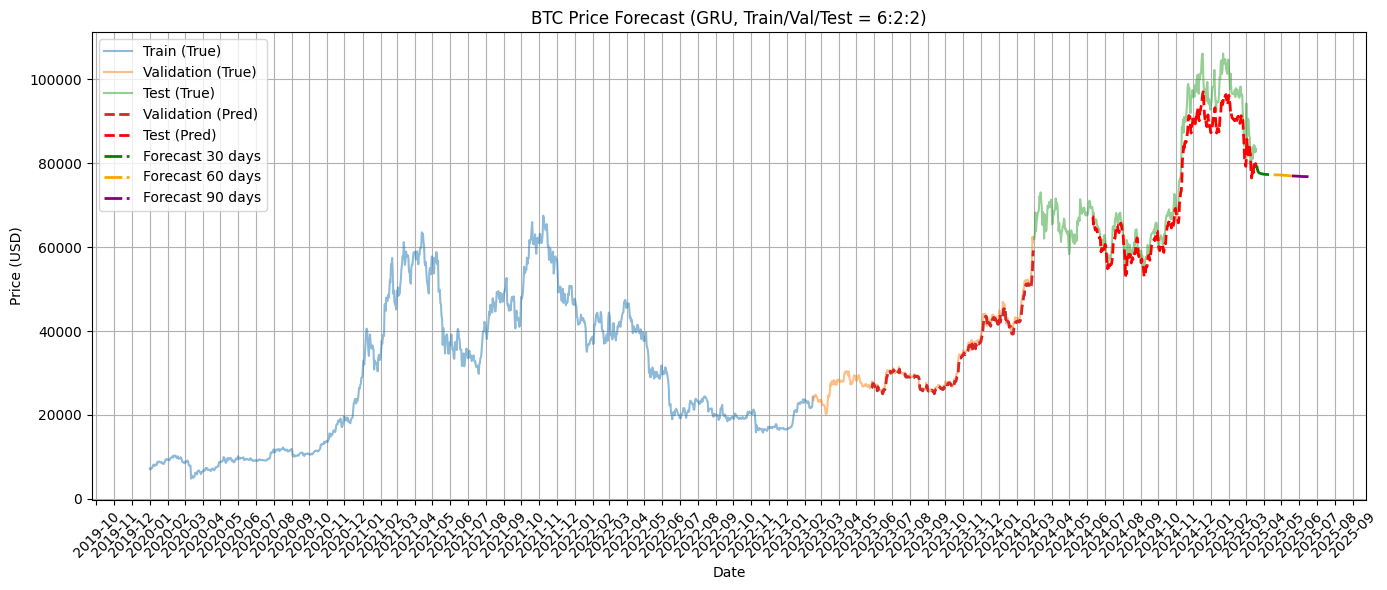

In [10]:
# 1️⃣ Hàm chuẩn hóa cột thời gian
def prepare_datetime(df):
    df = df.copy()
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
        df.dropna(subset=['Date'], inplace=True)
        df.set_index('Date', inplace=True)
    return df

# -----------------------------
# Chuẩn hóa 3 tập dữ liệu
train_df = prepare_datetime(train_df)
val_df = prepare_datetime(val_df)
test_df = prepare_datetime(test_df)

# -----------------------------
# Tạo mảng ngày tương lai (90 ngày)
t_last = test_df.index[-1]
future_dates_90 = pd.date_range(start=t_last + timedelta(days=1), periods=90)

# -----------------------------
# Hàm giải chuẩn hóa giá
def inverse_price(pred):
    dummy = np.zeros((len(pred), len(features)))
    dummy[:, target_index] = pred[:, 0] if pred.ndim > 1 else pred
    return scaler.inverse_transform(dummy)[:, target_index]

# -----------------------------
# Dự đoán + giải chuẩn hóa validation/test
y_pred_val_inv = inverse_price(model.predict(X_val))
y_pred_test_inv = inverse_price(model.predict(X_test))

# -----------------------------

# -----------------------------
# 7️⃣ Tạo mảng ngày tương ứng với dự đoán
dates_val = val_df.index[TIME_STEP:]
dates_test = test_df.index[TIME_STEP:]

# -----------------------------
# 8️⃣ Hàm vẽ đoạn forecast riêng biệt
def plot_forecast_segment(dates, values, label, color, start=0, end=None, style='-.'):
    end = end if end else len(values)
    plt.plot(dates[start:end], values[start:end], style, label=label, color=color, linewidth=2)

# -----------------------------
# Vẽ biểu đồ hoàn chỉnh
plt.figure(figsize=(14, 6))

# ✴ Giá thật
plt.plot(train_df.index, train_df['Price'], label='Train (True)', alpha=0.5)
plt.plot(val_df.index, val_df['Price'], label='Validation (True)', alpha=0.5)
plt.plot(test_df.index, test_df['Price'], label='Test (True)', alpha=0.5)

# ✴ Dự đoán
plt.plot(dates_val, y_pred_val_inv, '--', label='Validation (Pred)', linewidth=2)
plt.plot(dates_test, y_pred_test_inv, '--', label='Test (Pred)', color='red', linewidth=2)


# ✴ Dự báo tương lai
plot_forecast_segment(future_dates_90, future_90_rescaled, 'Forecast 30 days', 'green', 0, 30)
plot_forecast_segment(future_dates_90, future_90_rescaled, 'Forecast 60 days', 'orange', 30, 60)
plot_forecast_segment(future_dates_90, future_90_rescaled, 'Forecast 90 days', 'purple', 60, 90)

# ✴ Cấu hình trục thời gian
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))  # Hiển thị mỗi tháng
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  # Định dạng tháng-năm
plt.xticks(rotation=45)

# ✴ Giao diện tổng thể
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.title('BTC Price Forecast (GRU, Train/Val/Test = 6:2:2)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

